In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.offline as pyo
import plotly.express as px
import plotly.graph_objects as go

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [2]:
df = yf.download(['EXIDEIND.NS', 'ARE&M.NS', 'VGUARD.NS'], start='2015-01-01')['Close']
df

[*********************100%***********************]  3 of 3 completed


Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2015-01-01,NaN,167.786453,75.022072
2015-01-02,NaN,164.357697,77.481087
2015-01-05,NaN,165.203735,77.239601
2015-01-06,NaN,164.892044,72.964386
2015-01-07,NaN,163.556122,73.035812
...,...,...,...
2026-03-11,790.950012,311.500000,314.649994
2026-03-12,789.799988,310.000000,318.700012
2026-03-13,773.700012,296.600006,320.000000


In [3]:
df.dropna()

Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2023-10-18,624.535217,264.674469,297.650909
2023-10-19,621.028198,263.088715,302.269135
2023-10-20,611.822449,255.754532,306.390747
2023-10-23,601.252747,249.312363,295.465942
2023-10-25,594.920654,247.924805,297.551605
...,...,...,...
2026-03-11,790.950012,311.500000,314.649994
2026-03-12,789.799988,310.000000,318.700012
2026-03-13,773.700012,296.600006,320.000000


# Log Returns

In [5]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,ARE&M.NS,EXIDEIND.NS,VGUARD.NS
Date,,,
2023-10-19,-0.005631,-0.006009,0.015396
2023-10-20,-0.014934,-0.028273,0.013543
2023-10-23,-0.017427,-0.025512,-0.036308
2023-10-25,-0.010587,-0.005581,0.007034
2023-10-26,-0.010783,-0.015916,-0.001838
...,...,...,...
2026-03-11,0.001772,-0.017660,-0.004756
2026-03-12,-0.001455,-0.004827,0.012789
2026-03-13,-0.020596,-0.044188,0.004071


# Daily cummulative returns

In [7]:
daily_cum_returns = np.exp(log_returns.cumsum()) - 1

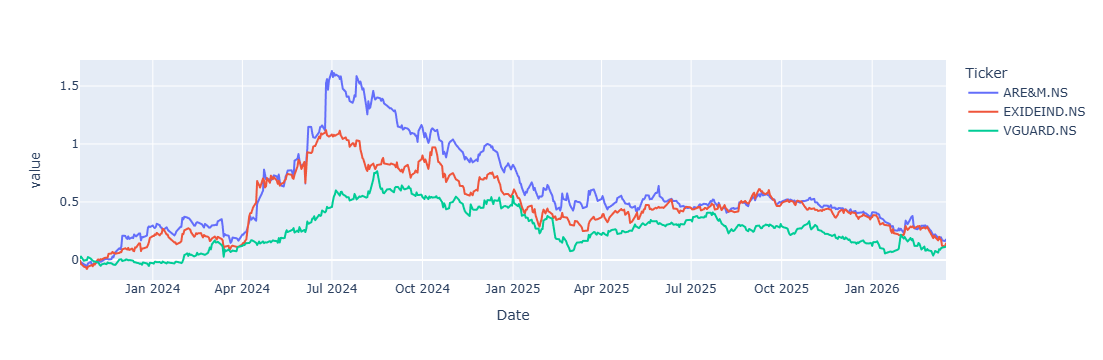

In [8]:
daily_cum_returns.plot()

# Wealth Index

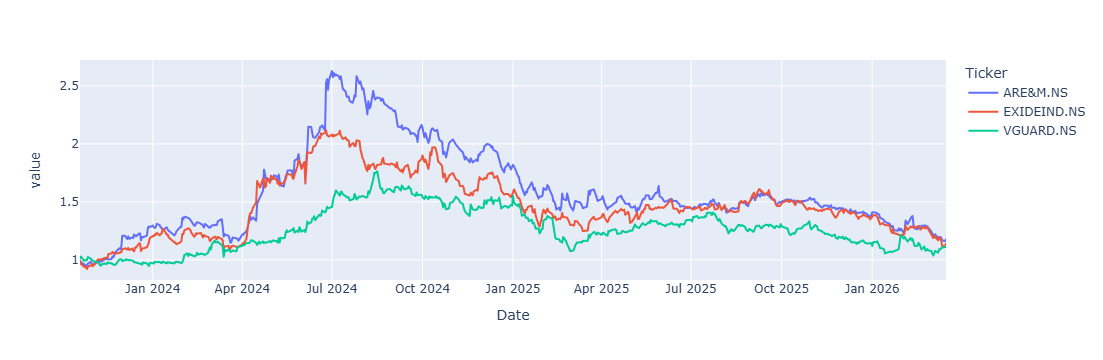

In [10]:
wealth_index = np.exp(log_returns.cumsum())
wealth_index.plot()

 Note: Both graps are coming same (Wealth index and daily cummulative returns) because mathematically they are the same curve—just shifted by a constant.

One starts at 0 (returns) and one starts at 1(wealth)

Risk / Quant / Backtesting → use wealth index

Reporting / Resume / Presentation → use cumulative returns (%)

# Drawdowns

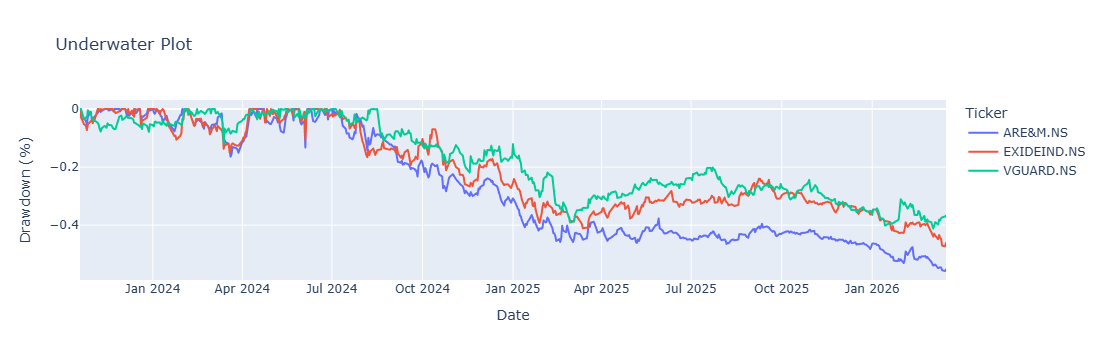

In [15]:
peak = wealth_index.cummax()

drawdown = wealth_index / peak - 1

drawdown.plot(title='Underwater Plot',
              labels={'value':'Drawdown (%)', 'index':'Date'})

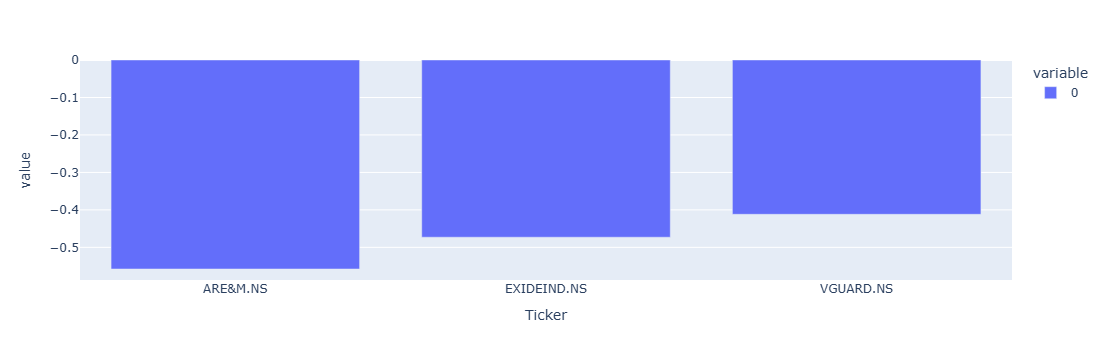

In [16]:
max_dd = drawdown.min()
max_dd.plot(kind='bar')

In [31]:
# wealth_index = np.exp(log_returns.cumsum())
# series = wealth_index['ARE&M.NS']

# peak = series.cummax()
# underwater = series < peak

# recovery_duration = []
# duration = 0

# for is_underwater in underwater:
#     if is_underwater:
#         duration += 1
#     else:
#         if duration > 0:
#             recovery_duration.append(duration)
#             duration = 0

In [35]:
series = wealth_index['ARE&M.NS']
peak = series.cummax()

recovery_duration = []
in_drawdown = False
duration = 0

for i in range(len(series)):

    if series.iloc[i] < peak.iloc[i]:
        in_drawdown = True
        duration += 1

    elif in_drawdown:
        recovery_duration.append(duration)
        duration = 0
        in_drawdown = False

if duration > 0:
    recovery_duration.append(duration)

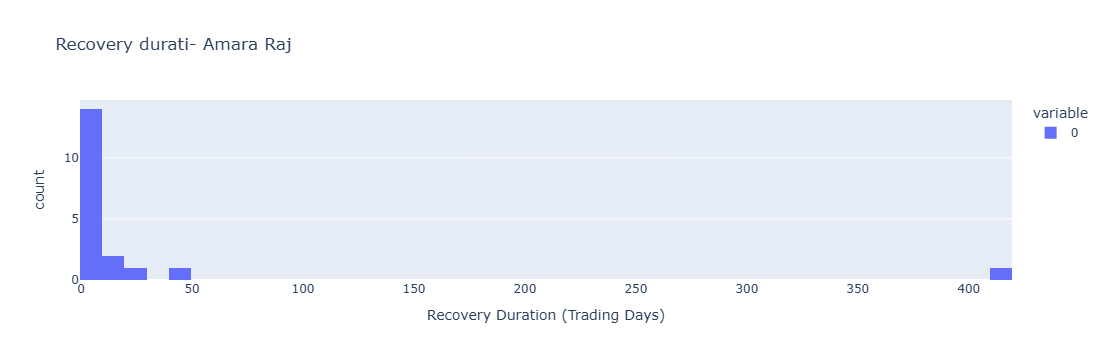

In [37]:
px.histogram(
    recovery_duration,
    nbins=70,
    title='Recovery durati- Amara Raj',
    labels={'value':'Recovery Duration (Trading Days)', 'count':'Frequency'}
).show()

In [49]:
series = wealth_index['EXIDEIND.NS']
peak = series.cummax()

recovery_duration = []
in_drawdown = False
duration = 0

for i in range(len(series)):

    if series.iloc[i] < peak.iloc[i]:
        in_drawdown = True
        duration += 1

    elif in_drawdown:
        recovery_duration.append(duration)
        duration = 0
        in_drawdown = False

if duration > 0:
    recovery_duration.append(duration)

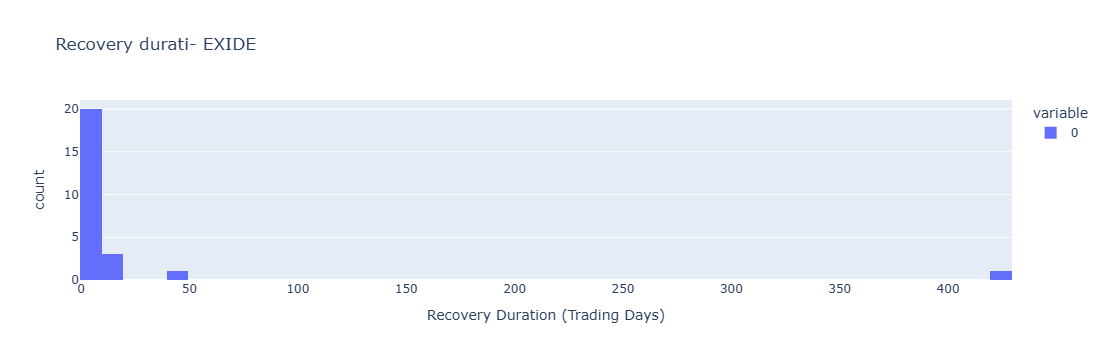

In [51]:
px.histogram(
    recovery_duration,
    nbins=70,
    title='Recovery durati- EXIDE',
    labels={'value':'Recovery Duration (Trading Days)', 'count':'Frequency'}
).show()

In [53]:
series = wealth_index['VGUARD.NS']
peak = series.cummax()

recovery_duration = []
in_drawdown = False
duration = 0

for i in range(len(series)):

    if series.iloc[i] < peak.iloc[i]:
        in_drawdown = True
        duration += 1

    elif in_drawdown:
        recovery_duration.append(duration)
        duration = 0
        in_drawdown = False

if duration > 0:
    recovery_duration.append(duration)

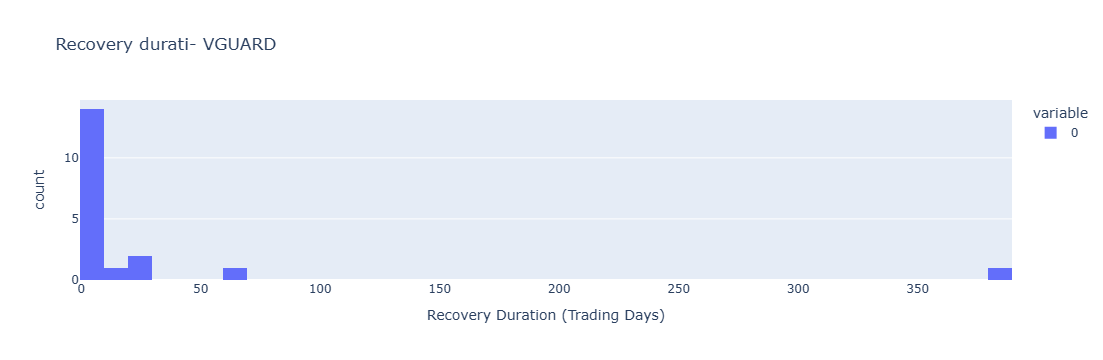

In [55]:
px.histogram(
    recovery_duration,
    nbins=70,
    title='Recovery durati- VGUARD',
    labels={'value':'Recovery Duration (Trading Days)', 'count':'Frequency'}
).show()